# Agglomerative and DBSCAN Credit-Risk Clustering Comparison

This notebook extends the v3 KMeans credit-risk segmentation logic with two alternative clustering methods:

1. **Agglomerative Clustering** — checks whether the risk groups behave like a hierarchical credit ladder.
2. **DBSCAN** — checks whether the data contains dense natural groups and isolated/noisy observations that may behave like outlier credit cases.

The point is not automatically to replace the v3 KMeans model. The goal is to provide a model-comparison and robustness section for the final project.

Expected conclusion style:

- KMeans remains useful when the goal is a clean 5-level rating-style ladder.
- Agglomerative is useful for validating whether clusters are hierarchically separable.
- DBSCAN is useful for detecting irregular/outlier observations, but it may not produce a clean business-friendly rating ladder.

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 1. Configuration

This notebook assumes the same six risk features used by the v3 non-financial KMeans model.

Agglomerative clustering and DBSCAN can be heavy on the full dataset because both methods may need many pairwise distance calculations. The notebook therefore defaults to a reproducible sample. Increase `MAX_ROWS_FOR_HEAVY_MODELS` or set it to `None` if your machine handles the full dataset comfortably.

In [19]:
PROJECT_ROOT = Path.cwd().parent

OUTPUT_DIR = PROJECT_ROOT / "credit_clustering_outputs_v3"

MODEL_PATH_CANDIDATES = [
    PROJECT_ROOT / "saved_models" / "nonfinancial_credit_scorecard_kmeans_k5_v3.joblib",
    PROJECT_ROOT / "nonfinancial_credit_scorecard_kmeans_k5_v3.joblib",
    OUTPUT_DIR / "nonfinancial_credit_scorecard_kmeans_k5_v3.joblib",
]

MODEL_PATH = next((p for p in MODEL_PATH_CANDIDATES if p.exists()), MODEL_PATH_CANDIDATES[0])

# Actual v3 output files from your project.
# The selected file must contain the six risk features below.
DATA_PATH_CANDIDATES = [
    OUTPUT_DIR / "clustered_panel_v3_by_financial_flag.parquet",
    OUTPUT_DIR / "issuer_year_feature_panel_v3.parquet",
    OUTPUT_DIR / "cluster_profile_v3_by_financial_flag.csv",
    OUTPUT_DIR / "cluster_metrics_v3_by_financial_flag.csv",
    OUTPUT_DIR / "cluster_k_tests_v3_by_financial_flag.csv",

    # Fallback names from earlier notebook versions
    PROJECT_ROOT / "outputs" / "nonfinancial_modeling_frame.parquet",
    PROJECT_ROOT / "outputs" / "nonfinancial_clustered_issuer_years.parquet",
    PROJECT_ROOT / "outputs" / "credit_cluster_modeling_frame.parquet",
    PROJECT_ROOT / "nonfinancial_modeling_frame.parquet",
    PROJECT_ROOT / "credit_cluster_modeling_frame.parquet",
]

SEGMENT_COL = "financial_flag"
TARGET_SEGMENT = "Non-financial"

FEATURE_COLS = [
    "structural_distress_risk",
    "earnings_risk",
    "operating_cashflow_risk",
    "liquidity_risk",
    "leverage_risk",
    "debt_service_risk",
]

# Keep this practical. Agglomerative/DBSCAN on 21k rows can be slow or memory-heavy.
MAX_ROWS_FOR_HEAVY_MODELS = 12000
RANDOM_STATE = 42

# Agglomerative settings
AGGLOMERATIVE_K_VALUES = [3, 4, 5, 6, 7, 8]
AGGLOMERATIVE_LINKAGE = "ward"

# DBSCAN settings.
# These are intentionally a grid because DBSCAN is very sensitive to eps/min_samples.
DBSCAN_EPS_VALUES = [0.25, 0.35, 0.50, 0.75, 1.00, 1.25, 1.50]
DBSCAN_MIN_SAMPLES_VALUES = [10, 25, 50, 100]

print("Project root:", PROJECT_ROOT)
print("Output dir:", OUTPUT_DIR)
print("Model path candidate:", MODEL_PATH)


Project root: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3
Output dir: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3\credit_clustering_outputs_v3
Model path candidate: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3\saved_models\nonfinancial_credit_scorecard_kmeans_k5_v3.joblib


## 2. Load the v3 artifact if available

The saved artifact is used for:

- the original v3 KMeans labels, if available;
- the same preprocessing pipeline, if available;
- the same feature list, if saved in the artifact.

If the artifact is missing, the notebook still runs comparison models using median imputation and standard scaling.

In [20]:
artifact = None
kmeans_pipe = None
kmeans_labels_from_artifact = None
feature_cols = FEATURE_COLS.copy()

if MODEL_PATH.exists():
    import joblib
    artifact = joblib.load(MODEL_PATH)
    print("Loaded artifact:", MODEL_PATH)
    print("Artifact keys:", sorted(list(artifact.keys())) if isinstance(artifact, dict) else type(artifact))

    if isinstance(artifact, dict):
        feature_cols = artifact.get("feature_cols", feature_cols)
        kmeans_pipe = artifact.get("pipeline") or artifact.get("model") or artifact.get("pipe")
        print("Feature columns:", feature_cols)
        print("Pipeline found:", kmeans_pipe is not None)
else:
    print("No v3 artifact found at:", MODEL_PATH)
    print("Proceeding with standalone preprocessing.")

Loaded artifact: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3\saved_models\nonfinancial_credit_scorecard_kmeans_k5_v3.joblib
Artifact keys: ['cluster_labels', 'cluster_profile_ranked', 'feature_cols', 'metrics_df', 'min_non_null_features', 'model_name', 'notes', 'pipeline', 'risk_rank', 'scorecard_cluster_features', 'scorecard_component_features', 'scorecard_domain_weights', 'scorecard_thresholds', 'segment', 'training_rows', 'version', 'winsor_caps']
Feature columns: ['structural_distress_risk', 'earnings_risk', 'operating_cashflow_risk', 'liquidity_risk', 'leverage_risk', 'debt_service_risk']
Pipeline found: True


## 3. Load the modeling frame

This notebook needs the **post-feature-engineering modeling frame**, not the raw EDGAR facts table.

The required columns are:

- `structural_distress_risk`
- `earnings_risk`
- `operating_cashflow_risk`
- `liquidity_risk`
- `leverage_risk`
- `debt_service_risk`

If this cell fails, export the final v3 modeling dataframe to one of the candidate paths, for example:

```python
modeling_df.to_parquet("outputs/nonfinancial_modeling_frame.parquet", index=False)
```

In [21]:
def load_first_existing_table(candidates, required_cols=None):
    required_cols = required_cols or []

    for path in candidates:
        if not path.exists():
            continue

        if path.suffix.lower() == ".parquet":
            candidate_df = pd.read_parquet(path)
        elif path.suffix.lower() == ".csv":
            candidate_df = pd.read_csv(path)
        else:
            continue

        missing = [col for col in required_cols if col not in candidate_df.columns]
        if missing:
            print(f"Skipping {path.name}: missing required feature columns {missing}")
            continue

        print("Loading:", path)
        return candidate_df, path

    return None, None


modeling_df, loaded_path = load_first_existing_table(
    DATA_PATH_CANDIDATES,
    required_cols=FEATURE_COLS,
)

if modeling_df is None:
    raise FileNotFoundError(
        "No usable v3 modeling frame found. The file must contain these columns:\n"
        + "\n".join(FEATURE_COLS)
        + "\n\nChecked paths:\n"
        + "\n".join(str(p) for p in DATA_PATH_CANDIDATES)
    )

print("Loaded shape:", modeling_df.shape)
print("Loaded file:", loaded_path)
print("Loaded columns:", modeling_df.columns.tolist())


Loading: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3\credit_clustering_outputs_v3\clustered_panel_v3_by_financial_flag.parquet
Loaded shape: (21265, 72)
Loaded file: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3\credit_clustering_outputs_v3\clustered_panel_v3_by_financial_flag.parquet
Loaded columns: ['ticker', 'cik', 'company_name', 'sic', 'fiscal_year', 'assets', 'assets_current', 'capex', 'cash', 'cfo', 'equity', 'goodwill', 'gross_profit', 'interest_expense', 'inventory', 'liabilities', 'liabilities_current', 'long_term_debt', 'net_income', 'operating_income', 'ppe', 'rd', 'receivables', 'revenue', 'sga', 'short_term_debt', 'major_sector', 'financial_flag', 'total_debt', 'fcf', 'log_assets', 'liabilities_to_assets', 'equity_to_assets', 'cash_to_assets', 'revenue_to_assets', 'net_income_to_assets', 'cfo_to_assets', 'debt_to_assets', 'debt_to_equity', 'current_ratio', 'qu

## 4. Validate features and filter to non-financial companies

We use the same non-financial segment logic as v3, because financial companies have structurally different balance sheets and ratios.

In [22]:
missing_features = [col for col in feature_cols if col not in modeling_df.columns]
if missing_features:
    raise KeyError(f"Missing required model features: {missing_features}")

work_df = modeling_df.copy()

if SEGMENT_COL in work_df.columns:
    work_df = work_df[work_df[SEGMENT_COL].eq(TARGET_SEGMENT)].copy()
else:
    print(f"Column {SEGMENT_COL!r} not found. Using all rows.")

feature_coverage = work_df[feature_cols].notna().mean(axis=1)
work_df["feature_coverage_pct"] = feature_coverage
work_df = work_df[feature_coverage >= 0.6667].copy()

print("Rows after segment/filter:", len(work_df))
work_df[feature_cols].describe().T

Rows after segment/filter: 11045


,count,mean,std,min,25%,50%,75%,max
structural_distress_risk,11045.0,0.110548,0.313585,0.0,0.000000,0.000000,0.000000,1.0
earnings_risk,11029.0,0.479602,0.407323,0.0,0.027216,0.397645,1.000000,1.0
operating_cashflow_risk,11045.0,0.400285,0.412334,0.0,0.000000,0.240352,0.948553,1.0
liquidity_risk,10958.0,0.370859,0.345296,0.0,0.012039,0.293917,0.677663,1.0
leverage_risk,10042.0,0.253953,0.266979,0.0,0.013832,0.175455,0.400470,1.0
debt_service_risk,4283.0,0.446164,0.406694,0.0,0.000000,0.406609,0.865648,1.0


## 5. Sample for heavier clustering methods

Agglomerative clustering and DBSCAN are useful comparison tools, but they are less scalable than MiniBatch/KMeans-style methods. Sampling keeps the notebook grader-friendly and reproducible.

In [23]:
if MAX_ROWS_FOR_HEAVY_MODELS is not None and len(work_df) > MAX_ROWS_FOR_HEAVY_MODELS:
    analysis_df = work_df.sample(MAX_ROWS_FOR_HEAVY_MODELS, random_state=RANDOM_STATE).copy()
    print(f"Using sample of {len(analysis_df):,} rows from {len(work_df):,} total rows.")
else:
    analysis_df = work_df.copy()
    print(f"Using full dataset: {len(analysis_df):,} rows.")

X_raw = analysis_df[feature_cols].copy()

Using full dataset: 11,045 rows.


## 6. Prepare the feature matrix

If the v3 artifact contains a preprocessing pipeline, we reuse it up to—but excluding—the final KMeans step. Otherwise, we use median imputation and standard scaling.

In [24]:
def transform_with_v3_preprocessor_or_default(X, kmeans_pipe=None):
    if kmeans_pipe is not None and hasattr(kmeans_pipe, "steps") and len(kmeans_pipe.steps) > 1:
        try:
            preprocessor = kmeans_pipe[:-1]
            X_prepared = preprocessor.transform(X)
            return X_prepared, "v3_preprocessor"
        except Exception as e:
            print("Could not use v3 preprocessor. Falling back to default scaler.")
            print("Reason:", repr(e))

    default_preprocessor = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    X_prepared = default_preprocessor.fit_transform(X)
    return X_prepared, "median_imputer_standard_scaler"

X_prepared, preprocessing_used = transform_with_v3_preprocessor_or_default(X_raw, kmeans_pipe=kmeans_pipe)
print("Prepared matrix shape:", X_prepared.shape)
print("Preprocessing used:", preprocessing_used)

Prepared matrix shape: (11045, 6)
Preprocessing used: v3_preprocessor


## 7. Baseline: reproduce v3 KMeans labels when possible

This creates the reference labels used to compare Agglomerative and DBSCAN. If the v3 pipeline is available, predictions come from the saved model. Otherwise, a fresh KMeans model with `k=5` is fitted as a fallback baseline.

In [25]:
def safe_internal_metrics(X, labels):
    labels = np.asarray(labels)
    mask = labels != -1  # DBSCAN noise excluded for internal cluster metrics
    valid_labels = labels[mask]
    X_valid = X[mask]

    unique = np.unique(valid_labels)
    if len(unique) < 2 or len(X_valid) <= len(unique):
        return {
            "clusters_ex_noise": len(unique),
            "noise_share": float((labels == -1).mean()),
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
            "davies_bouldin": np.nan,
        }

    return {
        "clusters_ex_noise": len(unique),
        "noise_share": float((labels == -1).mean()),
        "silhouette": silhouette_score(X_valid, valid_labels),
        "calinski_harabasz": calinski_harabasz_score(X_valid, valid_labels),
        "davies_bouldin": davies_bouldin_score(X_valid, valid_labels),
    }

if kmeans_pipe is not None:
    try:
        kmeans_labels = kmeans_pipe.predict(X_raw)
        baseline_source = "saved_v3_kmeans_pipeline"
    except Exception as e:
        print("Saved pipeline predict failed. Falling back to KMeans on prepared matrix.")
        print("Reason:", repr(e))
        kmeans_labels = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=20).fit_predict(X_prepared)
        baseline_source = "fresh_kmeans_k5"
else:
    kmeans_labels = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=20).fit_predict(X_prepared)
    baseline_source = "fresh_kmeans_k5"

analysis_df["kmeans_v3_label"] = kmeans_labels
print("Baseline source:", baseline_source)
pd.Series(kmeans_labels).value_counts().sort_index().rename("rows").to_frame()

Baseline source: saved_v3_kmeans_pipeline


,rows
0,1824
1,3531
2,2596
3,2072
4,1022


In [26]:
baseline_metrics = safe_internal_metrics(X_prepared, kmeans_labels)
baseline_metrics

{'clusters_ex_noise': 5,
 'noise_share': 0.0,
 'silhouette': 0.2989265155426715,
 'calinski_harabasz': 4995.751355214781,
 'davies_bouldin': 1.3115853216098083}

## 8. Agglomerative clustering

Why we do it:

- KMeans assumes roughly spherical clusters around centroids.
- Agglomerative clustering builds clusters bottom-up and can capture hierarchical structure.
- In a credit-risk context, this tests whether companies naturally merge into a risk ladder from healthy to distressed.

What to watch:

- It is more expensive than KMeans.
- It does not naturally produce soft distances/affinities like KMeans.
- It is useful as a validation/comparison model, not necessarily as the production scoring engine.

In [27]:
agglo_results = []
agglo_labels_by_k = {}

for k in AGGLOMERATIVE_K_VALUES:
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(X_prepared)
    agglo_labels_by_k[k] = labels

    metrics = safe_internal_metrics(X_prepared, labels)
    metrics.update({
        "method": "Agglomerative",
        "k": k,
        "ari_vs_kmeans": adjusted_rand_score(kmeans_labels, labels),
        "nmi_vs_kmeans": normalized_mutual_info_score(kmeans_labels, labels),
    })
    agglo_results.append(metrics)

agglo_results_df = pd.DataFrame(agglo_results)[[
    "method", "k", "clusters_ex_noise", "noise_share", "silhouette",
    "calinski_harabasz", "davies_bouldin", "ari_vs_kmeans", "nmi_vs_kmeans"
]].sort_values(["silhouette", "davies_bouldin"], ascending=[False, True])

agglo_results_df

,method,k,clusters_ex_noise,noise_share,silhouette,calinski_harabasz,davies_bouldin,ari_vs_kmeans,nmi_vs_kmeans
0,Agglomerative,3,3,0.0,0.388629,5349.344555,1.011354,0.356278,0.526229
3,Agglomerative,6,6,0.0,0.280209,4435.399365,1.338418,0.582229,0.631896
4,Agglomerative,7,7,0.0,0.271675,4180.943141,1.297612,0.597326,0.643143
2,Agglomerative,5,5,0.0,0.267795,4640.408891,1.372237,0.589419,0.634798
1,Agglomerative,4,4,0.0,0.259434,4766.543516,1.323442,0.483340,0.596383
5,Agglomerative,8,8,0.0,0.250219,3927.329560,1.275295,0.557837,0.627497


In [28]:
BEST_AGGLO_K = 5 if 5 in agglo_labels_by_k else int(agglo_results_df.iloc[0]["k"])
analysis_df["agglo_label"] = agglo_labels_by_k[BEST_AGGLO_K]

pd.crosstab(
    analysis_df["kmeans_v3_label"],
    analysis_df["agglo_label"],
    rownames=["KMeans v3"],
    colnames=[f"Agglomerative k={BEST_AGGLO_K}"],
    normalize="index",
).round(3)

Agglomerative k=5,0,1,2,3,4
KMeans v3,,,,,
0,0.000,0.037,0.340,0.000,0.623
1,0.021,0.070,0.000,0.739,0.170
2,0.048,0.810,0.000,0.053,0.089
3,0.000,0.000,0.937,0.000,0.063
4,1.000,0.000,0.000,0.000,0.000


### Agglomerative interpretation

Use this section in the report:

- If Agglomerative produces metrics close to KMeans and a high ARI/NMI versus KMeans, it supports the idea that the v3 risk groups are stable under a different clustering family.
- If Agglomerative produces better metrics but less interpretable groups, that is a trade-off: stronger geometry does not automatically mean a better credit-risk product.
- If Agglomerative strongly disagrees with KMeans, inspect the cross-tab above. It may mean the KMeans rating ladder is business-driven rather than naturally hierarchical.

## 9. DBSCAN

Why we do it:

- DBSCAN does not require choosing `k` upfront.
- It can identify observations that do not belong to any dense cluster (`label = -1`), which is useful for unusual/outlier credit cases.
- In credit risk, the DBSCAN noise group may contain unusual, distressed, or structurally different companies.

What to watch:

- DBSCAN is sensitive to `eps` and `min_samples`.
- It can collapse everything into one cluster or classify too many rows as noise.
- It is often less suitable for a clean rating ladder, but useful for outlier diagnostics.

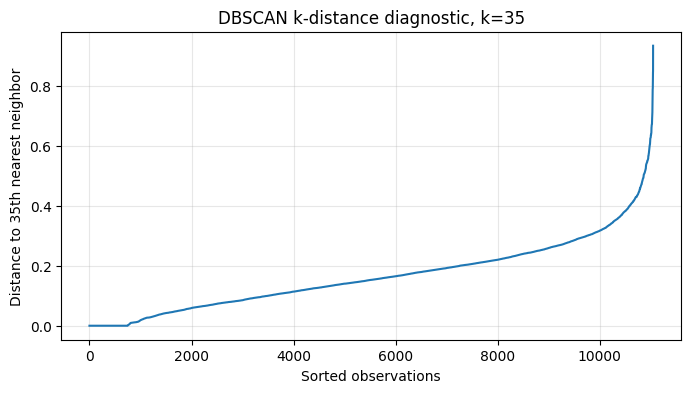

,k_distance
count,11045.000000
mean,0.166557
std,0.118535
min,0.000000
50%,0.152859
75%,0.230502
90%,0.312136
95%,0.381652
99%,0.549688
max,0.932975


In [29]:
# k-distance diagnostic for DBSCAN eps selection.
# The elbow of this curve is a practical candidate eps.
K_FOR_DISTANCE = 35
nn = NearestNeighbors(n_neighbors=K_FOR_DISTANCE)
nn.fit(X_prepared)
distances, _ = nn.kneighbors(X_prepared)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.title(f"DBSCAN k-distance diagnostic, k={K_FOR_DISTANCE}")
plt.xlabel("Sorted observations")
plt.ylabel(f"Distance to {K_FOR_DISTANCE}th nearest neighbor")
plt.grid(True, alpha=0.3)
plt.show()

pd.Series(k_distances).describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]).to_frame("k_distance")

In [30]:
dbscan_results = []
dbscan_labels_by_params = {}

for min_samples in DBSCAN_MIN_SAMPLES_VALUES:
    for eps in DBSCAN_EPS_VALUES:
        model = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        labels = model.fit_predict(X_prepared)
        dbscan_labels_by_params[(eps, min_samples)] = labels

        metrics = safe_internal_metrics(X_prepared, labels)
        metrics.update({
            "method": "DBSCAN",
            "eps": eps,
            "min_samples": min_samples,
            "ari_vs_kmeans": adjusted_rand_score(kmeans_labels, labels),
            "nmi_vs_kmeans": normalized_mutual_info_score(kmeans_labels, labels),
            "largest_cluster_share": pd.Series(labels[labels != -1]).value_counts(normalize=True).max() if np.any(labels != -1) else np.nan,
        })
        dbscan_results.append(metrics)

dbscan_results_df = pd.DataFrame(dbscan_results)
dbscan_results_df = dbscan_results_df[[
    "method", "eps", "min_samples", "clusters_ex_noise", "noise_share",
    "largest_cluster_share", "silhouette", "calinski_harabasz", "davies_bouldin",
    "ari_vs_kmeans", "nmi_vs_kmeans"
]].sort_values(["clusters_ex_noise", "noise_share", "silhouette"], ascending=[False, True, False])

dbscan_results_df

,method,eps,min_samples,clusters_ex_noise,noise_share,largest_cluster_share,silhouette,calinski_harabasz,davies_bouldin,ari_vs_kmeans,nmi_vs_kmeans
0,DBSCAN,0.25,10,7,0.027343,0.905427,0.203021,574.697549,1.025752,0.098908,0.282618
14,DBSCAN,0.25,50,6,0.133001,0.870092,0.226928,908.646590,0.845173,0.153994,0.293546
15,DBSCAN,0.35,50,4,0.032322,0.914296,0.296361,1077.740030,1.167568,0.097174,0.279882
7,DBSCAN,0.25,25,4,0.073517,0.921919,0.300505,980.569666,1.138512,0.104321,0.256697
21,DBSCAN,0.25,100,4,0.233771,0.910079,0.295077,977.003050,0.637818,0.171740,0.283084
1,DBSCAN,0.35,10,3,0.006700,0.894084,0.333131,1498.045827,1.402514,0.099854,0.277210
23,DBSCAN,0.50,100,3,0.010774,0.899140,0.316218,1707.784616,0.939664,0.103164,0.300570
8,DBSCAN,0.35,25,3,0.016388,0.901694,0.340590,1447.974214,1.399770,0.099016,0.272504
3,DBSCAN,0.75,10,2,0.000000,0.889452,0.384169,2805.207783,1.239437,0.107291,0.286347
10,DBSCAN,0.75,25,2,0.000000,0.889452,0.384169,2805.207783,1.239437,0.107291,0.286347


In [31]:
# Choose a practical DBSCAN model:
# - at least 2 clusters excluding noise
# - noise share not insane
# - largest cluster not too dominant
candidate_dbscan = dbscan_results_df[
    (dbscan_results_df["clusters_ex_noise"] >= 2)
    & (dbscan_results_df["noise_share"] <= 0.50)
    & (dbscan_results_df["largest_cluster_share"].fillna(1) <= 0.90)
].copy()

if len(candidate_dbscan) == 0:
    print("No clean DBSCAN candidate found with current grid. Selecting lowest-noise multi-cluster attempt if available.")
    candidate_dbscan = dbscan_results_df[dbscan_results_df["clusters_ex_noise"] >= 2].copy()

if len(candidate_dbscan) > 0:
    best_dbscan_row = candidate_dbscan.sort_values(
        ["silhouette", "noise_share"], ascending=[False, True]
    ).iloc[0]
    BEST_DBSCAN_EPS = float(best_dbscan_row["eps"])
    BEST_DBSCAN_MIN_SAMPLES = int(best_dbscan_row["min_samples"])
    dbscan_labels = dbscan_labels_by_params[(BEST_DBSCAN_EPS, BEST_DBSCAN_MIN_SAMPLES)]
else:
    # fallback to first grid row
    best_dbscan_row = dbscan_results_df.iloc[0]
    BEST_DBSCAN_EPS = float(best_dbscan_row["eps"])
    BEST_DBSCAN_MIN_SAMPLES = int(best_dbscan_row["min_samples"])
    dbscan_labels = dbscan_labels_by_params[(BEST_DBSCAN_EPS, BEST_DBSCAN_MIN_SAMPLES)]

analysis_df["dbscan_label"] = dbscan_labels
print("Selected DBSCAN eps:", BEST_DBSCAN_EPS)
print("Selected DBSCAN min_samples:", BEST_DBSCAN_MIN_SAMPLES)

pd.Series(dbscan_labels).value_counts().sort_index().rename("rows").to_frame()

Selected DBSCAN eps: 0.5
Selected DBSCAN min_samples: 50


,rows
-1,46
0,9824
1,1175


In [32]:
pd.crosstab(
    analysis_df["kmeans_v3_label"],
    analysis_df["dbscan_label"],
    rownames=["KMeans v3"],
    colnames=["DBSCAN label (-1 = noise)"],
    normalize="index",
).round(3)

DBSCAN label (-1 = noise),-1,0,1
KMeans v3,,,
0,0.000,1.000,0.000
1,0.001,0.979,0.020
2,0.001,0.952,0.047
3,0.000,1.000,0.000
4,0.040,0.000,0.960


### DBSCAN interpretation

Use this section in the report:

- If DBSCAN creates one dominant cluster and a noise group, it suggests the data is more continuous than naturally separated into density islands.
- If many observations are marked as noise, DBSCAN is acting more like an outlier detector than a rating segmentation model.
- If the noise group overlaps heavily with the distressed KMeans cluster, DBSCAN supports the idea that near-default firms are structurally unusual.
- If DBSCAN disagrees with KMeans, that is not automatically bad: DBSCAN and KMeans optimize different concepts.

## 10. Visual comparison using PCA

PCA is only for visualization. The actual clustering is performed on the six scaled risk features, not on the 2D plot.

In [33]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_prepared)
plot_df = analysis_df.copy()
plot_df["pca_1"] = X_pca[:, 0]
plot_df["pca_2"] = X_pca[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.4763776  0.22352121]


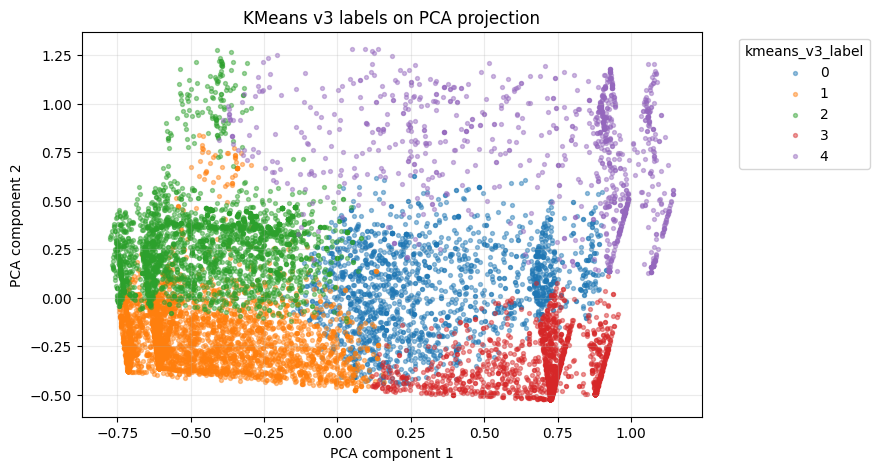

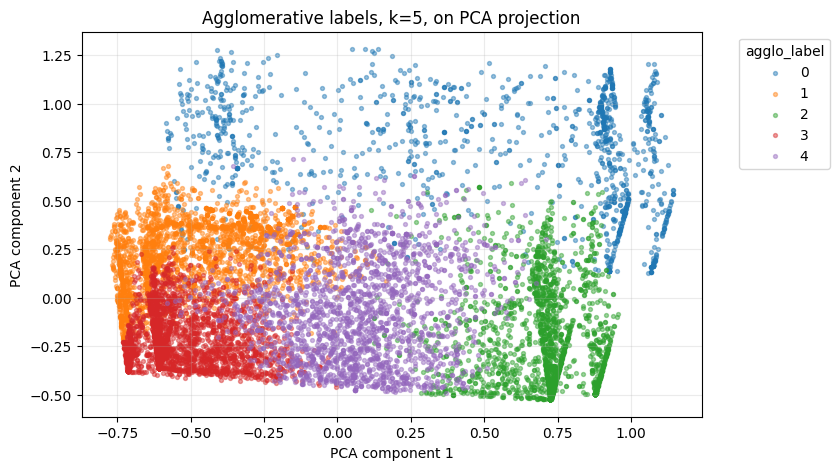

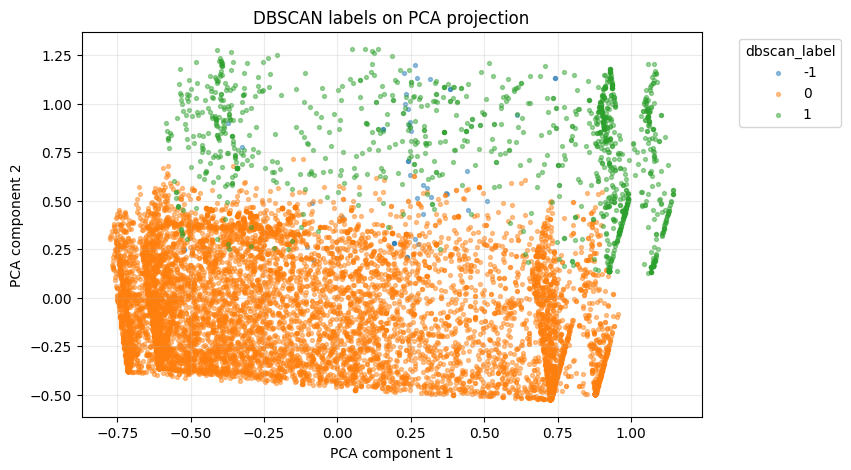

In [34]:
def scatter_by_label(df, label_col, title):
    plt.figure(figsize=(8, 5))
    labels = df[label_col].astype(str)
    for lab in sorted(labels.unique()):
        sub = df[labels == lab]
        plt.scatter(sub["pca_1"], sub["pca_2"], s=8, alpha=0.45, label=lab)
    plt.title(title)
    plt.xlabel("PCA component 1")
    plt.ylabel("PCA component 2")
    plt.legend(title=label_col, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True, alpha=0.25)
    plt.show()

scatter_by_label(plot_df, "kmeans_v3_label", "KMeans v3 labels on PCA projection")
scatter_by_label(plot_df, "agglo_label", f"Agglomerative labels, k={BEST_AGGLO_K}, on PCA projection")
scatter_by_label(plot_df, "dbscan_label", "DBSCAN labels on PCA projection")

## 11. Profile clusters by original risk features

These profiles make the model comparison business-readable.

In [35]:
def profile_by_label(df, label_col, feature_cols):
    profile = (
        df.groupby(label_col)
        .agg(
            rows=(feature_cols[0], "size"),
            **{f"median_{c}": (c, "median") for c in feature_cols},
        )
        .reset_index()
        .sort_values(label_col)
    )
    profile["row_share"] = profile["rows"] / profile["rows"].sum()
    return profile

kmeans_profile = profile_by_label(analysis_df, "kmeans_v3_label", feature_cols)
agglo_profile = profile_by_label(analysis_df, "agglo_label", feature_cols)
dbscan_profile = profile_by_label(analysis_df, "dbscan_label", feature_cols)

kmeans_profile

,kmeans_v3_label,rows,median_structural_distress_risk,median_earnings_risk,median_operating_cashflow_risk,median_liquidity_risk,median_leverage_risk,median_debt_service_risk,row_share
0,0,1824,0.0,0.904913,0.541991,0.582357,0.270158,0.824307,0.165143
1,1,3531,0.0,0.012391,0.000000,0.086409,0.067011,0.000000,0.319692
2,2,2596,0.0,0.169214,0.010945,0.753751,0.263942,0.122691,0.235038
3,3,2072,0.0,1.000000,1.000000,0.000000,0.033855,1.000000,0.187596
4,4,1022,1.0,1.000000,1.000000,0.540786,0.702859,1.000000,0.092531


In [36]:
agglo_profile

,agglo_label,rows,median_structural_distress_risk,median_earnings_risk,median_operating_cashflow_risk,median_liquidity_risk,median_leverage_risk,median_debt_service_risk,row_share
0,0,1221,1.0,1.000000,0.987109,0.539982,0.723404,0.923866,0.110548
1,1,2417,0.0,0.163001,0.000000,0.752988,0.252816,0.002368,0.218832
2,2,2561,0.0,1.000000,1.000000,0.036453,0.084073,1.000000,0.231870
3,3,2748,0.0,0.000000,0.000000,0.072106,0.059098,0.000000,0.248800
4,4,2098,0.0,0.542276,0.395116,0.336718,0.168788,0.680035,0.189950


In [37]:
dbscan_profile

,dbscan_label,rows,median_structural_distress_risk,median_earnings_risk,median_operating_cashflow_risk,median_liquidity_risk,median_leverage_risk,median_debt_service_risk,row_share
0,-1,46,1.0,0.000000,0.994909,0.490794,0.650000,0.656105,0.004165
1,0,9824,0.0,0.367488,0.208124,0.265652,0.131912,0.389314,0.889452
2,1,1175,1.0,1.000000,0.985176,0.542756,0.725298,0.948482,0.106383


## 12. Final comparison table

This table is the core artifact for the project write-up.

In [38]:
comparison_rows = []

base = safe_internal_metrics(X_prepared, kmeans_labels)
base.update({
    "method": "KMeans v3 baseline",
    "model_detail": baseline_source,
    "ari_vs_kmeans": 1.0,
    "nmi_vs_kmeans": 1.0,
})
comparison_rows.append(base)

agg = safe_internal_metrics(X_prepared, analysis_df["agglo_label"].values)
agg.update({
    "method": "Agglomerative",
    "model_detail": f"ward, k={BEST_AGGLO_K}",
    "ari_vs_kmeans": adjusted_rand_score(kmeans_labels, analysis_df["agglo_label"].values),
    "nmi_vs_kmeans": normalized_mutual_info_score(kmeans_labels, analysis_df["agglo_label"].values),
})
comparison_rows.append(agg)

db = safe_internal_metrics(X_prepared, analysis_df["dbscan_label"].values)
db.update({
    "method": "DBSCAN",
    "model_detail": f"eps={BEST_DBSCAN_EPS}, min_samples={BEST_DBSCAN_MIN_SAMPLES}",
    "ari_vs_kmeans": adjusted_rand_score(kmeans_labels, analysis_df["dbscan_label"].values),
    "nmi_vs_kmeans": normalized_mutual_info_score(kmeans_labels, analysis_df["dbscan_label"].values),
})
comparison_rows.append(db)

comparison_df = pd.DataFrame(comparison_rows)[[
    "method", "model_detail", "clusters_ex_noise", "noise_share", "silhouette",
    "calinski_harabasz", "davies_bouldin", "ari_vs_kmeans", "nmi_vs_kmeans"
]]
comparison_df

,method,model_detail,clusters_ex_noise,noise_share,silhouette,calinski_harabasz,davies_bouldin,ari_vs_kmeans,nmi_vs_kmeans
0,KMeans v3 baseline,saved_v3_kmeans_pipeline,5,0.000000,0.298927,4995.751355,1.311585,1.000000,1.000000
1,Agglomerative,"ward, k=5",5,0.000000,0.267795,4640.408891,1.372237,0.589419,0.634798
2,DBSCAN,"eps=0.5, min_samples=50",2,0.004165,0.385630,2750.202975,1.225361,0.105970,0.283783


## 13. Suggested conclusion

A good final-project conclusion usually looks like this:

> KMeans remains the preferred production segmentation model because it creates a stable, interpretable five-level credit-risk ladder. Agglomerative clustering is useful as a robustness check because it tests whether the same observations form hierarchical risk groups under a different clustering family. DBSCAN is useful as an outlier and density diagnostic, especially for identifying observations that do not fit any dense cluster. However, DBSCAN is less suitable as the main rating-style model because it may produce noise labels, unstable cluster counts, or one dominant cluster depending on the selected density threshold.

If your actual metrics show Agglomerative outperforming KMeans, phrase it carefully:

> Agglomerative clustering showed competitive or stronger internal separation metrics, but the final KMeans solution was retained because the project objective is an interpretable credit-style scoring ladder, not only geometric cluster optimization.

If DBSCAN marks a lot of observations as noise:

> DBSCAN behaved more like an outlier detector than a full segmentation model. This is still useful because unusual issuer-years may warrant manual review or conservative treatment in credit monitoring.

## 14. Optional export

Save comparison outputs for the report.

In [39]:
EXPORT_DIR = PROJECT_ROOT / "outputs" / "alternative_clustering"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

comparison_df.to_csv(EXPORT_DIR / "alternative_clustering_comparison.csv", index=False)
agglo_results_df.to_csv(EXPORT_DIR / "agglomerative_grid_results.csv", index=False)
dbscan_results_df.to_csv(EXPORT_DIR / "dbscan_grid_results.csv", index=False)

kmeans_profile.to_csv(EXPORT_DIR / "kmeans_profile_sample.csv", index=False)
agglo_profile.to_csv(EXPORT_DIR / "agglomerative_profile_sample.csv", index=False)
dbscan_profile.to_csv(EXPORT_DIR / "dbscan_profile_sample.csv", index=False)

print("Exported to:", EXPORT_DIR)

Exported to: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\08_final_project_3\outputs\alternative_clustering
